# Example: Visualising a network

The example present two ways of visualising a network
- **mathplotlib** - matplotlib should probably be considered the "quick and dirty" way a drawing graphs. Under the hood it repurposes a scatterplot and hides the axes in order to give the impression of having a graph diagram.
- **cytoscape** - [cytoscape](https://js.cytoscape.org/) is a dedicated graph theory library written in javascript that has bindings ([ipycytoscape](https://ipycytoscape.readthedocs.io/en/latest/)) for working with Jupyter. It has numerous benefits over matplotlib since is has dedicated and interactive graphs diagrams among many other features.


Both methods work by converting the echo `OptimisationGraph` to a [networkx](https://networkx.org/) graph and then rendering that graph.

One current limitation of the approach is that the networkx graph only includes the echo nodes and the edges that connect them. It doesn't draw anything to represent the ports themselves. Having the ports as things that can be interacted with could very useful in the future.

### Import a simple network

First we need a network to visualise. Here can import a simple pre-built BTM (Behind-the-meter) network comprising of a connection point with a load, inverter, solar and pv attached.

In [45]:
from echo.examples.networks import simple_btm_network

## Visualising a network with Matplotlib


By default the matplotlib picture is rendered as a static image that cannot be interacted with. If we wanted to be explicit we could add the line `%matplotlib inline` to the notebook.

We can turn the plot interactive by uncommenting the line to following cell and rerunning the notebook.

> Note: Requires ipympl to be installed (`python -m pip install ipympl`). You may need to restart Jupyter lab/notebook after installation for this extension to be recognised.

> **Warning:** The interactive version seems to have a bug which results in the network being redrawn over the top of the previous one.

In [46]:
# %matplotlib widget

Add the standard matplotlib import statement. Disable automatic redrawing since this results in the figure being drawn whilst you are creating it (in addition to when you explicitly request it to be drawn).

In [47]:
import matplotlib.pyplot as plt

plt.ioff()

Matplotlib offers two ["coding" styles](https://matplotlib.org/stable/users/explain/quick_start.html#coding-styles) - an explicit (aka OOP) style and an implicit (aka pyplot) style. 

The follow example uses the explicit style. We recommend this style since it gives us more control over plotting and less scope for bugs and subtle errors.

In this style, we *explicitly* create `Figures` and `Axes`. `Axes` are (unfortunate) matplotlib jargon and what we we would call plots or subplots. See here for more [info](https://matplotlib.org/stable/users/explain/axes/index.html).

The following cod creates a figure called `network_figure` and then adds a single plot to it called `network_axes`.

In [48]:
network_figure = plt.figure()
network_axes = network_figure.add_subplot()

Next we draw our network `simple_btm_network` on the plot `network_axes`, choosing to also display the node labels.

In [49]:
simple_btm_network.draw_on_axes(axes=network_axes, with_labels=True)

Finally we use the ipython `display` function to render the network

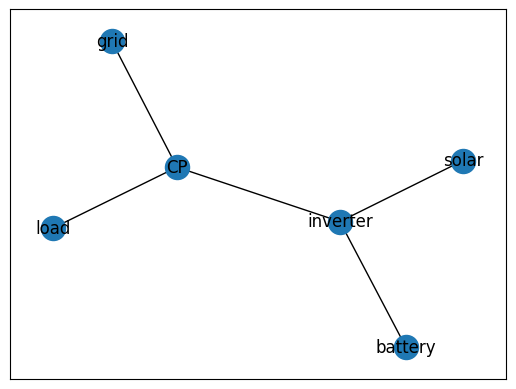

In [50]:
display(network_figure)

Behind the scenes we are using networkx to do the drawing for us, through a call to [draw_networkx](https://networkx.org/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw_networkx.html#networkx.drawing.nx_pylab.draw_networkx). By passing parameters down to this function, we can customise the style of the graph in order to make it look how we want.


Here we define a dictionary called `style` and set various style attributes of the nodes, edges and labels. In this style dictionary, the keys must match the keyword arguments that `draw_networkx` accepts.

In [51]:
style = {
    "edgecolors": "#FFFFFF",        # node border color
    "linewidths": 3,                # node border width
    "edge_color": "#CCCCCC",        # edge color of edges
    "width": 2,                     # edge width
    "horizontalalignment": "left",  # label horizontal position
    "verticalalignment": "top",     # label vertical position
    "font_color": "#555555",        # label text color
}

Similar to above we create a matplotlib figure and axes and draw the network, but this time passing the style parameters using a dictionary unpacking.

The rendered graph is less visually busy than the default (show above)

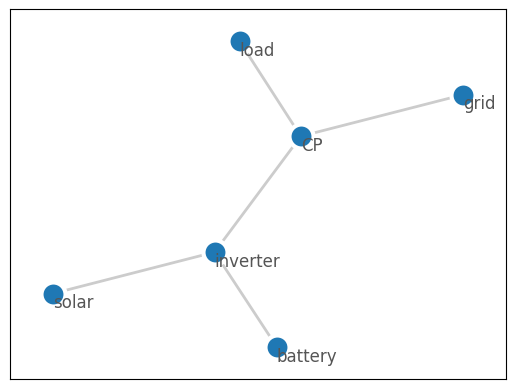

In [52]:
styled_network_figure = plt.figure()
styled_network_axes = styled_network_figure.add_subplot()
simple_btm_network.draw_on_axes(axes=styled_network_axes, with_labels=True, **style)
display(styled_network_figure)

## Visualising a network with Cytoscape

Cytoscape renders an interactive graph. The default interactions are:
- The graph can be repositioned (panning) by clicking and dragging with the mouse
- Zooming can be achieved with the mouse wheel.
- Nodes can be reposition by click and dragging on an individual node.
- Nodes can be clicked but not selected.

The [javascript documentation](https://js.cytoscape.org/#getting-started) will give you sense of how powerful cytoscape is. The [ipycytoscape documentation](https://ipycytoscape.readthedocs.io/en/latest/) is much more limited however.

Import `ipycytoscape` and create a `CytoscapeWidget`.

The `wheel_sensitivity` controls how quicker the graph zooms when scrolling the mouse wheel. Feel free to change this value if the zoom is difficult to control.

In [53]:
import ipycytoscape

wheel_sensitivity=0.2  # default value is 1.0
cyto = ipycytoscape.CytoscapeWidget(wheel_sensitivity=wheel_sensitivity)

Convert our `OptimisationGraph` to a networkx graph.

In [54]:
G = simple_btm_network.convert_to_nx()

Add the networkx graph to the Cytoscape widget `cyto`.

In [55]:
cyto.graph.add_graph_from_networkx(G)

In a similar way to the matplotlib example we can set styling options for how to renders the nodes and edges. We also tell cytoscape to use the id of the node as the node label.

In [56]:
style = [
    {
        "selector": "node",
        "style": {
            "background-color": '#2980B9',
            "border-color": "#FFFFFF",
            "border-width": 4,
            "label": "data(id)"
        },
    },
    {
        "selector": "edge",
        "style": {
            'line-color': '#cccccc',
        },
    },
]

cyto.set_style(style)

Draw the interactive cytoscape widget.

In [57]:
display(cyto)

CytoscapeWidget(cytoscape_layout={'name': 'cola'}, cytoscape_style=[{'selector': 'node', 'style': {'background…